# Feature Engineering
This notebook demonstrates the comprehensive feature engineering pipeline including:
- Sequence features (order, recency, frequency)
- Job text features (NLP-based similarity)
- Session behavior features (action patterns)

In [8]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline.data_processor import DataProcessor

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Data

In [9]:
# Initialize data processor
processor = DataProcessor()
jobs, x_train, y_train, x_test = processor.load_data()

print(f"Jobs: {len(jobs)}")
print(f"Train sessions: {len(x_train)}")
print(f"Test sessions: {len(x_test)}")

Jobs: 21917
Train sessions: 15882
Test sessions: 1819


## 2. Prepare Sequences

In [21]:
# Prepare sequences (parse lists from strings)
x_train = processor.prepare_sequences(x_train)
x_test = processor.prepare_sequences(x_test)

print("\nSample data:")
x_train.head()


Sample data:


,session_id,job_ids,actions,jobs_list,actions_list,seq_length
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view...","[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",8
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']","[84, 257, 252, 250]","[view, view, view, view]",4
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a...","[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",7
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",8
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",6


## 3. Extract Sequence Features
Features based on order, recency, and frequency of jobs in sequences

In [11]:
# Extract sequence features only
x_train_seq = processor.add_features(x_train, feature_types=['sequence'])

# Display new sequence features
sequence_cols = [col for col in x_train_seq.columns if col not in x_train.columns]
print(f"\nSequence features added ({len(sequence_cols)}):")
print(sequence_cols)

# Show sample
x_train_seq[['session_id', 'seq_length', 'unique_jobs_count', 
             'most_frequent_job_count', 'job_transitions', 'max_consecutive_views']].head(10)

Extracting sequence features...

Sequence features added (15):
['first_job', 'last_job', 'second_job', 'second_last_job', 'unique_jobs_count', 'unique_jobs_ratio', 'most_frequent_job', 'most_frequent_job_count', 'most_frequent_job_ratio', 'job_last_positions', 'avg_job_position', 'job_transitions', 'job_transitions_ratio', 'max_consecutive_views', 'avg_consecutive_views']


,session_id,seq_length,unique_jobs_count,most_frequent_job_count,job_transitions,max_consecutive_views
0,0,8,8,1,7,1
1,1,4,4,1,3,1
2,2,7,7,1,6,1
3,3,8,8,1,7,1
4,4,6,6,1,5,1
5,5,4,4,1,3,1
6,6,4,4,1,3,1
7,7,3,3,1,2,1
8,8,6,6,1,5,1
9,9,9,9,1,8,1


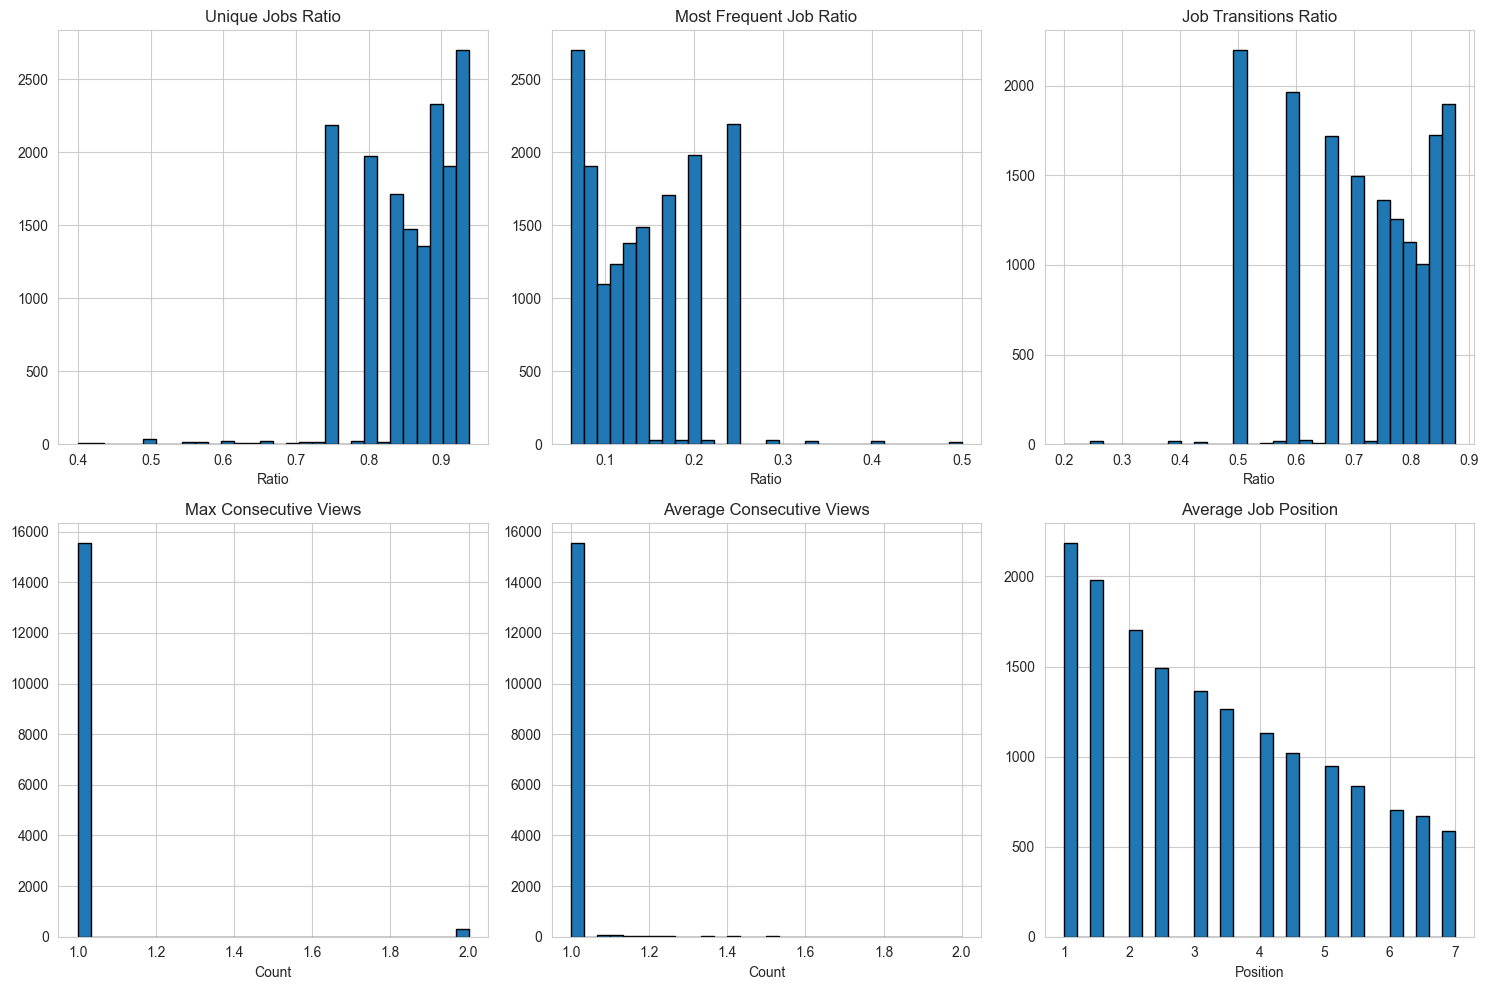

In [12]:
# Visualize sequence features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(x_train_seq['unique_jobs_ratio'], bins=30, edgecolor='black')
axes[0, 0].set_title('Unique Jobs Ratio')
axes[0, 0].set_xlabel('Ratio')

axes[0, 1].hist(x_train_seq['most_frequent_job_ratio'], bins=30, edgecolor='black')
axes[0, 1].set_title('Most Frequent Job Ratio')
axes[0, 1].set_xlabel('Ratio')

axes[0, 2].hist(x_train_seq['job_transitions_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Job Transitions Ratio')
axes[0, 2].set_xlabel('Ratio')

axes[1, 0].hist(x_train_seq['max_consecutive_views'], bins=30, edgecolor='black')
axes[1, 0].set_title('Max Consecutive Views')
axes[1, 0].set_xlabel('Count')

axes[1, 1].hist(x_train_seq['avg_consecutive_views'], bins=30, edgecolor='black')
axes[1, 1].set_title('Average Consecutive Views')
axes[1, 1].set_xlabel('Count')

axes[1, 2].hist(x_train_seq['avg_job_position'], bins=30, edgecolor='black')
axes[1, 2].set_title('Average Job Position')
axes[1, 2].set_xlabel('Position')

plt.tight_layout()
plt.show()

## 4. Extract Session Behavior Features
Features based on user actions (view vs apply patterns)

In [13]:
# Extract session features
x_train_session = processor.add_features(x_train_seq, feature_types=['session'])

# Display new session features
session_cols = [col for col in x_train_session.columns if col not in x_train_seq.columns]
print(f"\nSession behavior features added ({len(session_cols)}):")
print(session_cols)

# Show sample
x_train_session[['session_id', 'view_count', 'apply_count', 'view_ratio', 'apply_ratio',
                 'view_to_apply_count', 'action_change_ratio']].head(10)

Extracting session behavior features...

Session behavior features added (16):
['view_count', 'apply_count', 'view_ratio', 'apply_ratio', 'first_action_is_apply', 'last_action_is_apply', 'view_to_apply_count', 'apply_to_view_count', 'action_change_ratio', 'first_apply_position', 'first_apply_position_ratio', 'applied_jobs', 'applied_jobs_count', 'unique_applied_jobs_count', 'viewed_jobs', 'viewed_not_applied_count']


,session_id,view_count,apply_count,view_ratio,apply_ratio,view_to_apply_count,action_change_ratio
0,0,8,0,0.888889,0.000000,0,0.000000
1,1,4,0,0.800000,0.000000,0,0.000000
2,2,2,5,0.250000,0.625000,1,0.142857
3,3,0,8,0.000000,0.888889,0,0.000000
4,4,0,6,0.000000,0.857143,0,0.000000
5,5,0,4,0.000000,0.800000,0,0.000000
6,6,0,4,0.000000,0.800000,0,0.000000
7,7,0,3,0.000000,0.750000,0,0.000000
8,8,0,6,0.000000,0.857143,0,0.000000
9,9,0,9,0.000000,0.900000,0,0.000000


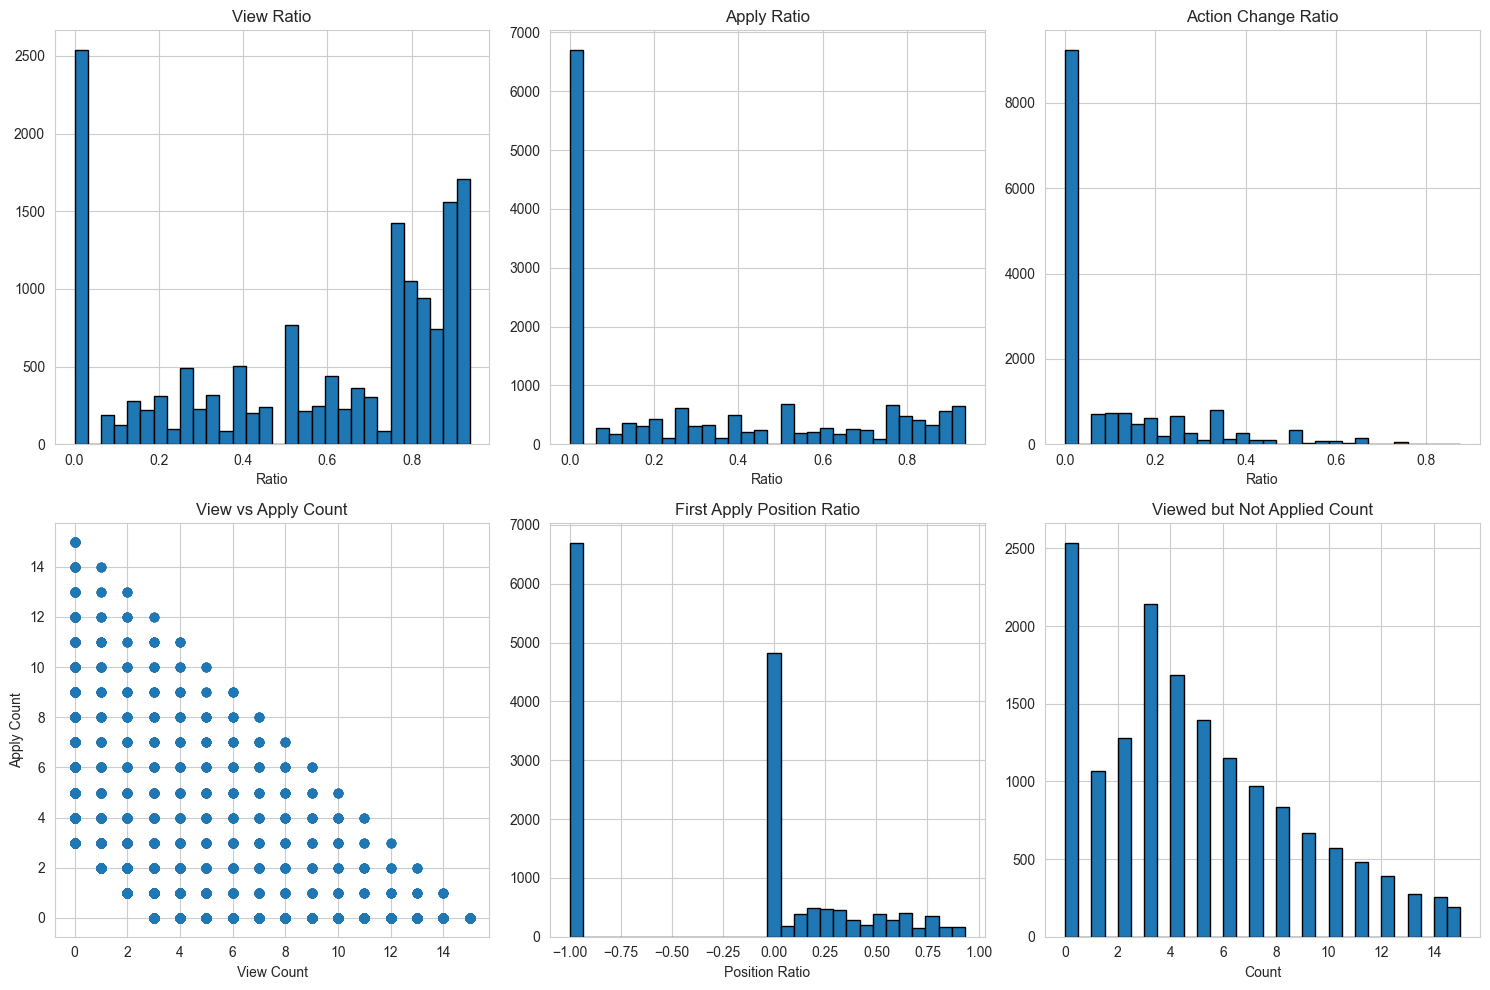

In [15]:
# Visualize session behavior features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(x_train_session['view_ratio'], bins=30, edgecolor='black')
axes[0, 0].set_title('View Ratio')
axes[0, 0].set_xlabel('Ratio')

axes[0, 1].hist(x_train_session['apply_ratio'], bins=30, edgecolor='black')
axes[0, 1].set_title('Apply Ratio')
axes[0, 1].set_xlabel('Ratio')

axes[0, 2].hist(x_train_session['action_change_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Action Change Ratio')
axes[0, 2].set_xlabel('Ratio')

axes[1, 0].scatter(x_train_session['view_count'], x_train_session['apply_count'], alpha=0.3)
axes[1, 0].set_title('View vs Apply Count')
axes[1, 0].set_xlabel('View Count')
axes[1, 0].set_ylabel('Apply Count')

axes[1, 1].hist(x_train_session['first_apply_position_ratio'], bins=30, edgecolor='black')
axes[1, 1].set_title('First Apply Position Ratio')
axes[1, 1].set_xlabel('Position Ratio')

axes[1, 2].hist(x_train_session['viewed_not_applied_count'], bins=30, edgecolor='black')
axes[1, 2].set_title('Viewed but Not Applied Count')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 5. Extract Job Text Features (NLP)
Features based on text similarity between jobs using TF-IDF and cosine similarity

In [ ]:
# Debug: Check jobs structure
print(f"Jobs type: {type(jobs)}")
print(f"Jobs length: {len(jobs)}")
if isinstance(jobs, dict):
    first_key = list(jobs.keys())[0]
    print(f"First key type: {type(first_key)}, value: {first_key}")
    print(f"First job data: {jobs[first_key]}")
elif isinstance(jobs, list):
    print(f"First job: {jobs[0]}")
    if jobs and 'JobId' in jobs[0]:
        print("Jobs is a list of dictionaries with JobId")


In [20]:
# Extract text features (this takes longer due to NLP processing)
print("Extracting NLP-based text features (this may take a few minutes)...")
x_train_text = processor.add_features(x_train_session.head(1000), feature_types=['text'])  # Start with subset

# Display new text features
text_cols = [col for col in x_train_text.columns if col not in x_train_session.columns]
print(f"\nText similarity features added ({len(text_cols)}):")
print(text_cols)

# Show sample
x_train_text[['session_id', 'avg_job_similarity', 'max_job_similarity', 
              'first_last_similarity', 'avg_skills_count', 'total_skills_count']].head(10)

Extracting NLP-based text features (this may take a few minutes)...
Extracting job text features with NLP...
Building TF-IDF matrix for job descriptions...


TypeError: string indices must be integers, not 'str'

In [ ]:
# Visualize text similarity features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(x_train_text['avg_job_similarity'], bins=30, edgecolor='black')
axes[0, 0].set_title('Average Job Similarity')
axes[0, 0].set_xlabel('Similarity Score')

axes[0, 1].hist(x_train_text['max_job_similarity'], bins=30, edgecolor='black')
axes[0, 1].set_title('Max Job Similarity')
axes[0, 1].set_xlabel('Similarity Score')

axes[1, 0].hist(x_train_text['first_last_similarity'], bins=30, edgecolor='black')
axes[1, 0].set_title('First-Last Job Similarity')
axes[1, 0].set_xlabel('Similarity Score')

axes[1, 1].hist(x_train_text['total_skills_count'], bins=30, edgecolor='black')
axes[1, 1].set_title('Total Unique Skills Count')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 6. Extract All Features at Once

In [ ]:
# Extract all features for a small sample first
print("Extracting all features for training set (sample)...")
x_train_all = processor.add_features(x_train.head(500), feature_types=['all'])

print(f"\nOriginal columns: {x_train.shape[1]}")
print(f"With all features: {x_train_all.shape[1]}")
print(f"New features added: {x_train_all.shape[1] - x_train.shape[1]}")

# Show all column names
print("\nAll feature columns:")
for col in x_train_all.columns:
    print(f"  - {col}")

## 7. Feature Statistics Summary

In [ ]:
# Get numeric columns only
numeric_cols = x_train_all.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col not in ['session_id', 'seq_length']]

# Summary statistics
print("Feature Statistics Summary:")
x_train_all[feature_cols].describe().T

## 8. Feature Correlation Analysis

In [ ]:
# Calculate correlation matrix for numeric features
correlation_matrix = x_train_all[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

## 9. Save Processed Features

In [ ]:
# Process full datasets (may take time)
print("Processing full training set...")
x_train_features = processor.add_features(x_train, feature_types=['sequence', 'session'])

print("Processing test set...")
x_test_features = processor.add_features(x_test, feature_types=['sequence', 'session'])

# Save to CSV
x_train_features.to_csv('../Data/x_train_with_features.csv', index=False)
x_test_features.to_csv('../Data/x_test_with_features.csv', index=False)

print("\nFeatures saved!")
print(f"Training set: {x_train_features.shape}")
print(f"Test set: {x_test_features.shape}")